# Repeated evaluation runs — visualization

Loads `summary.json` from `scripts/run_evaluation_repeated.sh` / `scripts/summarize_evaluation_runs.py`.

- **Subsystems 1–3** are the three rubric blocks (4 criteria each → **12 categories** total).
- **Four pipelines** (MARS + three ablations) are compared on every chart.

Set `SUMMARY_PATH` below to a `summary.json`, or leave `None` to use the newest under `results/evaluation_runs/`.

In [12]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

PROJECT_ROOT = Path("..").resolve()
EVAL_RUNS = PROJECT_ROOT / "results" / "evaluation_runs"
RUBRIC_PATH = PROJECT_ROOT / "config" / "evaluation_rubric.yaml"

SUMMARY_PATH: str | None = None

# Preferred order of pipelines (matches run_evaluation.py)
CONDITION_ORDER = [
    "evaluation",
    "ablation_3agent",
    "ablation_1agent_rag",
    "ablation_1agent_no_rag",
]

COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]


def resolve_summary_path(explicit: str | None) -> Path:
    if explicit:
        p = Path(explicit)
        return p if p.is_absolute() else (PROJECT_ROOT / p).resolve()
    if not EVAL_RUNS.is_dir():
        raise FileNotFoundError(f"No directory {EVAL_RUNS}; run the bash script first.")
    candidates = sorted(
        EVAL_RUNS.glob("**/summary.json"),
        key=lambda x: x.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No summary.json under {EVAL_RUNS}")
    return candidates[0]


with open(RUBRIC_PATH, encoding="utf-8") as f:
    rubric = yaml.safe_load(f)

DIMENSION_META = rubric["dimensions"]
ALL_DIM_KEYS = list(DIMENSION_META.keys())
SYS1_KEYS = [k for k in ALL_DIM_KEYS if k.startswith("system1_")]
SYS2_KEYS = [k for k in ALL_DIM_KEYS if k.startswith("system2_")]
SYS3_KEYS = [k for k in ALL_DIM_KEYS if k.startswith("system3_")]


def short_label(dim_key: str) -> str:
    return DIMENSION_META[dim_key].get("short_name", dim_key)


def full_name(dim_key: str) -> str:
    return DIMENSION_META[dim_key].get("name", dim_key)


summary_path = resolve_summary_path(SUMMARY_PATH)
print("Using:", summary_path)

with open(summary_path, encoding="utf-8") as f:
    summary = json.load(f)

conditions = summary.get("conditions") or {}
print("num_runs:", summary.get("num_runs"), "| runs:", summary.get("run_names"))


def condition_label(ck: str) -> str:
    block = conditions.get(ck) or {}
    return block.get("label", ck)


def dim_mean(ck: str, dim_key: str) -> float | None:
    block = conditions.get(ck) or {}
    d = block.get(dim_key)
    if isinstance(d, dict) and "mean" in d:
        return float(d["mean"])
    return None


present_keys = [ck for ck in CONDITION_ORDER if ck in conditions]
if not present_keys:
    present_keys = list(conditions.keys())

labels_ordered = [condition_label(ck) for ck in present_keys]
colors_ordered = [COLORS[i % len(COLORS)] for i in range(len(present_keys))]
print("Pipelines:", labels_ordered)

Using: /Users/tarjeihage/Downloads/MARS_ablation3_cursorMoveGraphGeneration/results/evaluation_runs/20260414_160529/summary.json
num_runs: 5 | runs: ['run_01', 'run_02', 'run_03', 'run_04', 'run_05']
Pipelines: ['MARS (Full Pipeline)', '3-Agent Sequential (No RAG/KG)', '1-Agent + RAG/KG', '1-Agent (No RAG/KG)']


In [13]:
# Weighted average overview
rows = []
for ck in present_keys:
    block = conditions.get(ck) or {}
    wt = block.get("weighted_avg")
    if not isinstance(wt, dict):
        continue
    rows.append(
        {
            "condition_key": ck,
            "label": block.get("label", ck),
            "mean": wt["mean"],
            "std": wt["std"],
            "min": wt["min"],
            "max": wt["max"],
        }
    )

df_weighted = pd.DataFrame(rows).sort_values("mean", ascending=False)
df_weighted

,condition_key,label,mean,std,min,max
0,evaluation,MARS (Full Pipeline),4.784,0.173868,4.50,4.92
3,ablation_1agent_no_rag,1-Agent (No RAG/KG),4.018,0.151228,3.83,4.17
1,ablation_3agent,3-Agent Sequential (No RAG/KG),3.934,0.766472,3.25,4.83
2,ablation_1agent_rag,1-Agent + RAG/KG,3.850,0.412492,3.17,4.17


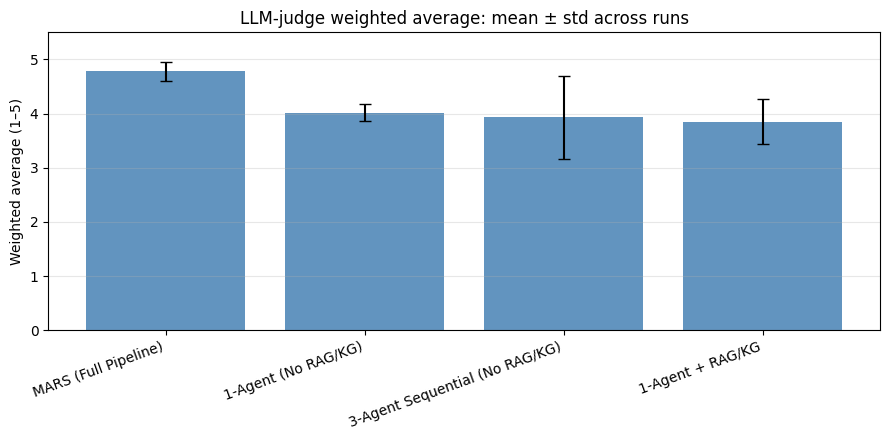

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = df_weighted["label"].tolist()
x = np.arange(len(labels))
means = df_weighted["mean"].to_numpy()
stds = df_weighted["std"].to_numpy()
ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", ecolor="black", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Weighted average (1–5)")
ax.set_title("LLM-judge weighted average: mean ± std across runs")
ax.set_ylim(0, 5.5)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Spider charts — all 12 rubric categories

One radar per **pipeline** (mean scores); axes are the 12 dimensions (short labels).

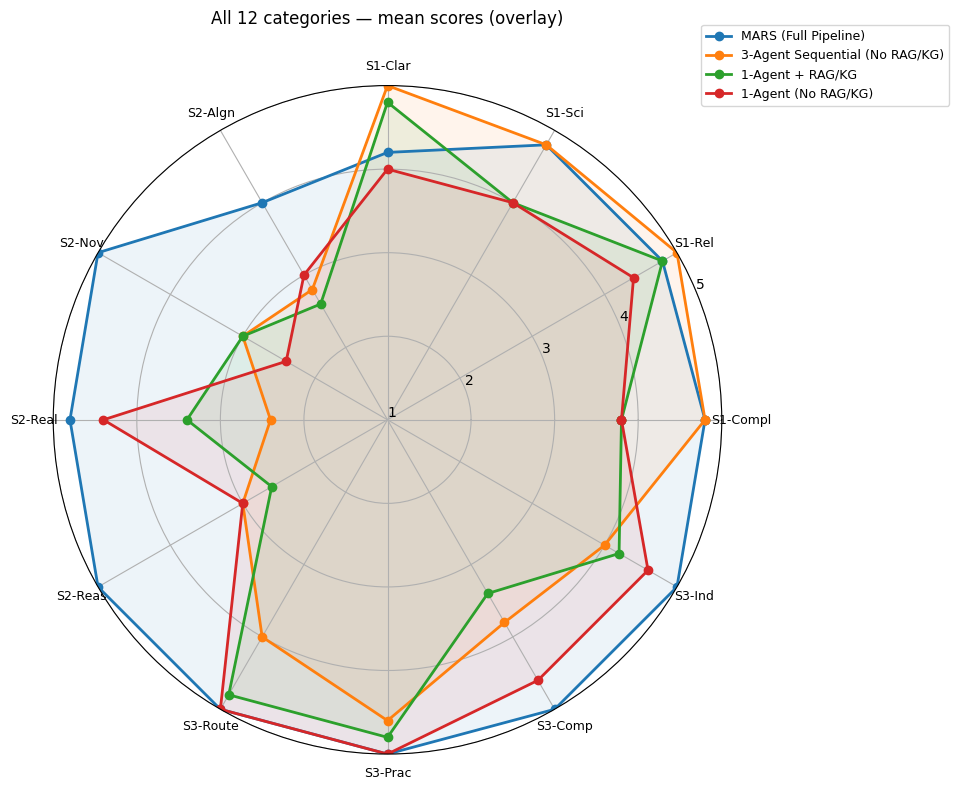

In [15]:
def radar_closed(values: list[float]) -> tuple[np.ndarray, np.ndarray]:
    n = len(values)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    v = np.asarray(values, dtype=float)
    angles = np.concatenate([angles, angles[:1]])
    v = np.concatenate([v, v[:1]])
    return angles, v


dim_keys_12 = ALL_DIM_KEYS
tick_labels = [short_label(k) for k in dim_keys_12]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection="polar"))
for ck, lab, col in zip(present_keys, labels_ordered, colors_ordered):
    vals = [dim_mean(ck, k) for k in dim_keys_12]
    if any(v is None for v in vals):
        continue
    ang, v = radar_closed([float(x) for x in vals])
    ax.plot(ang, v, "o-", linewidth=2, label=lab, color=col)
    ax.fill(ang, v, alpha=0.08, color=col)

ax.set_xticks(np.linspace(0, 2 * np.pi, len(dim_keys_12), endpoint=False))
ax.set_xticklabels(tick_labels, fontsize=9)
ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title("All 12 categories — mean scores (overlay)", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

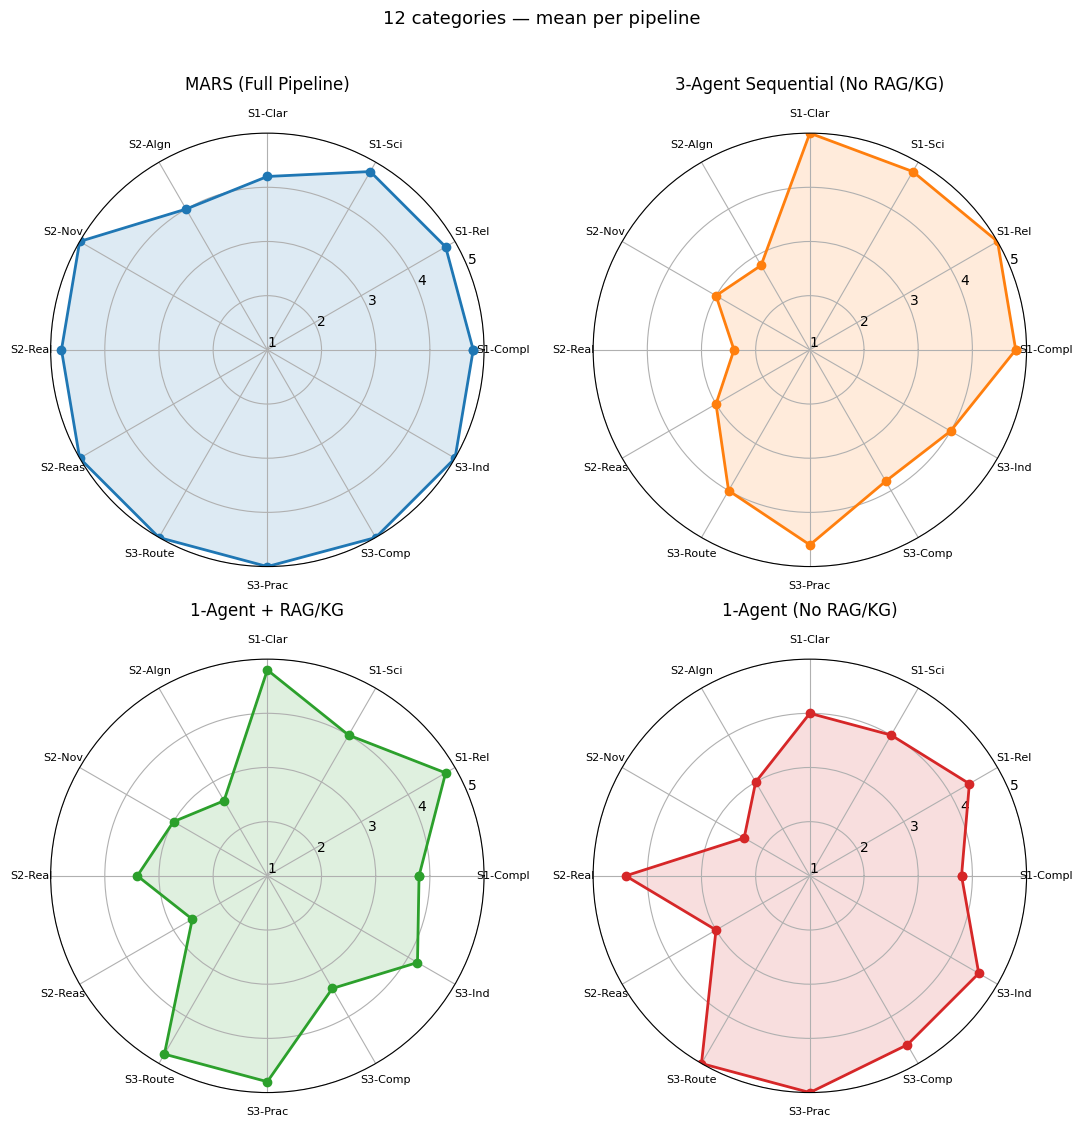

In [16]:
# Same data: one spider per pipeline (easier to read than overlay)
n_p = len(present_keys)
ncols = 2
nrows = int(np.ceil(n_p / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(11, 5.5 * nrows), subplot_kw=dict(projection="polar")
)
axes = np.atleast_2d(axes).ravel()

for idx, ck in enumerate(present_keys):
    ax = axes[idx]
    vals = [dim_mean(ck, k) for k in dim_keys_12]
    if any(v is None for v in vals):
        ax.set_title(condition_label(ck) + " (missing data)")
        continue
    ang, v = radar_closed([float(x) for x in vals])
    col = colors_ordered[idx]
    ax.plot(ang, v, "o-", linewidth=2, color=col)
    ax.fill(ang, v, alpha=0.15, color=col)
    ax.set_xticks(np.linspace(0, 2 * np.pi, len(dim_keys_12), endpoint=False))
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylim(1, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_title(condition_label(ck), y=1.08)

for j in range(len(present_keys), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("12 categories — mean per pipeline", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## Spider charts — subsystem averages

For each pipeline, **average of the four criteria** in System 1, System 2, and System 3 → **3-axis** radar (one point per subsystem).

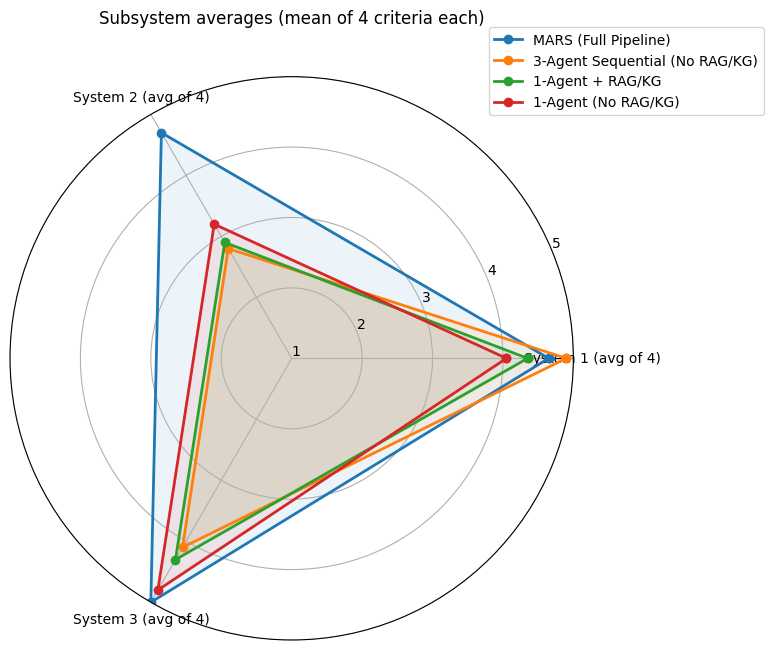

In [17]:
def subsystem_means(ck: str) -> tuple[float | None, float | None, float | None]:
    def avg(keys: list[str]) -> float | None:
        xs = [dim_mean(ck, k) for k in keys]
        if any(x is None for x in xs):
            return None
        return float(np.mean(xs))

    return avg(SYS1_KEYS), avg(SYS2_KEYS), avg(SYS3_KEYS)


sys_labels = ["System 1 (avg of 4)", "System 2 (avg of 4)", "System 3 (avg of 4)"]
n_sys = 3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection="polar"))
ax.set_xticks(np.linspace(0, 2 * np.pi, n_sys, endpoint=False))
ax.set_xticklabels(sys_labels, fontsize=10)

for ck, lab, col in zip(present_keys, labels_ordered, colors_ordered):
    m1, m2, m3 = subsystem_means(ck)
    if None in (m1, m2, m3):
        continue
    ang, v = radar_closed([m1, m2, m3])
    ax.plot(ang, v, "o-", linewidth=2, label=lab, color=col)
    ax.fill(ang, v, alpha=0.08, color=col)

ax.set_ylim(1, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title("Subsystem averages (mean of 4 criteria each)", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

## Grouped bar charts — each **subsystem** (Systems 1–3)

Within each subsystem, bars compare the **four pipelines** on each criterion (mean ± std across repeated runs).

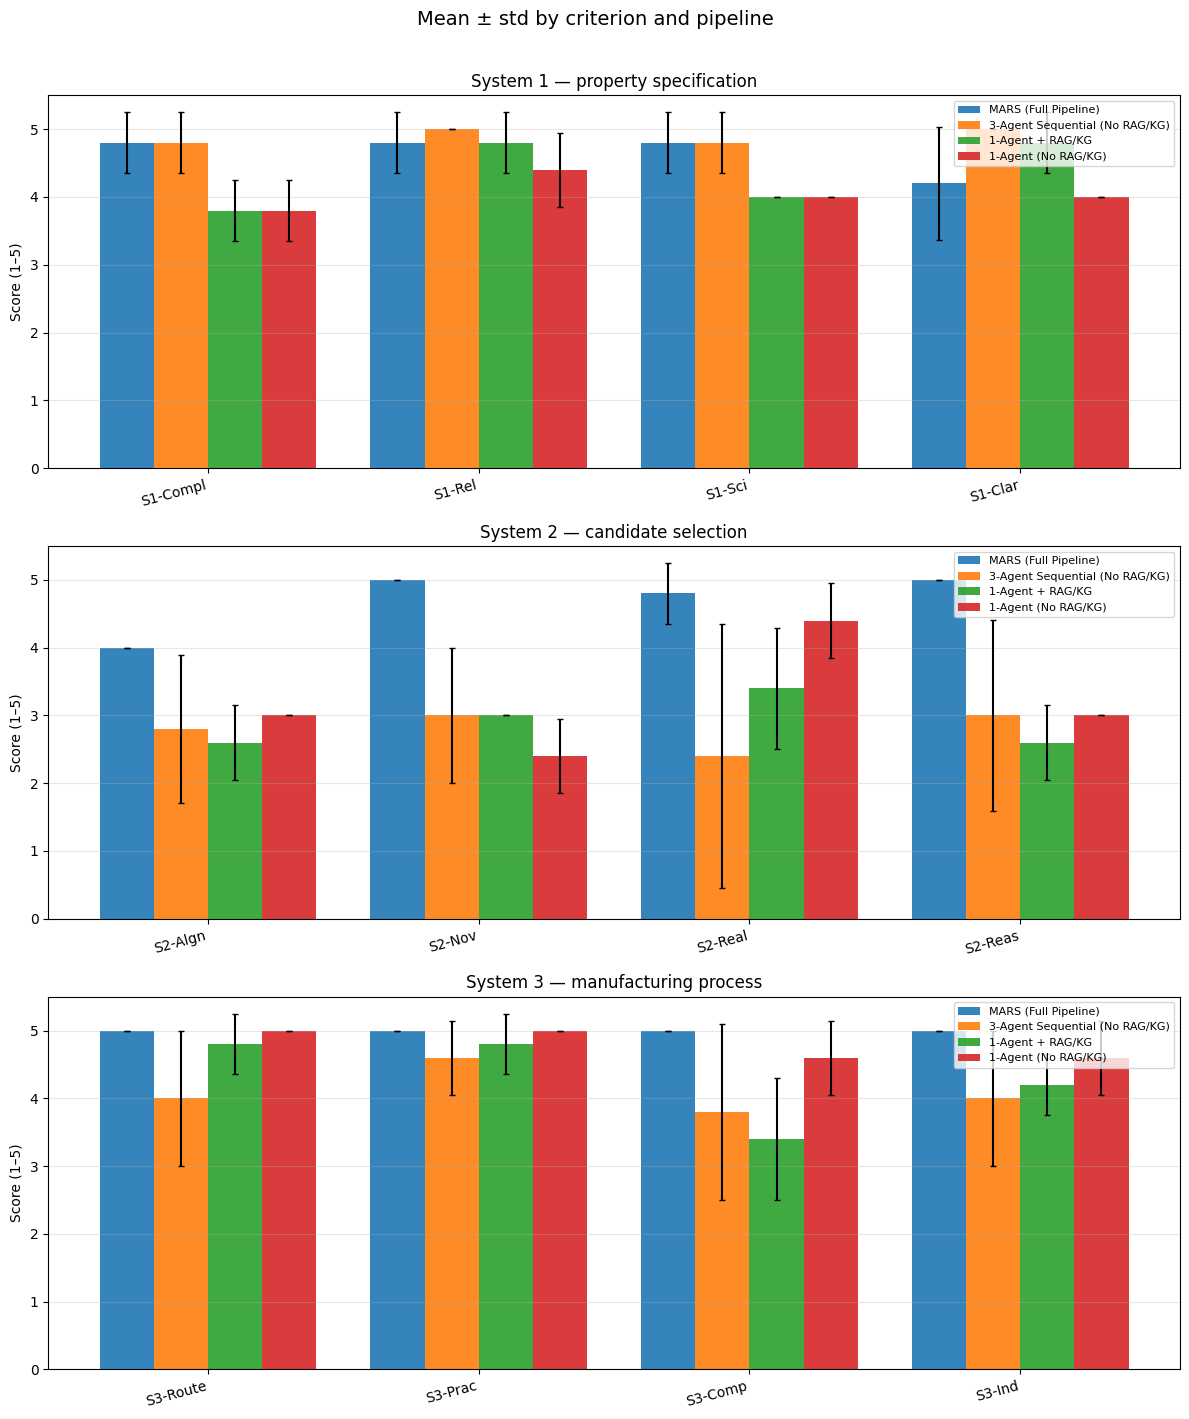

In [18]:
def grouped_bars_subsystem(ax, dim_keys: list[str], title: str) -> None:
    n_c = len(dim_keys)
    n_cond = len(present_keys)
    x = np.arange(n_c)
    width = 0.8 / n_cond
    for i, ck in enumerate(present_keys):
        means = []
        stds = []
        for dk in dim_keys:
            block = (conditions.get(ck) or {}).get(dk)
            if isinstance(block, dict):
                means.append(float(block["mean"]))
                stds.append(float(block["std"]))
            else:
                means.append(np.nan)
                stds.append(0.0)
        pos = x - 0.4 + width / 2 + i * width
        ax.bar(
            pos,
            means,
            width,
            yerr=stds,
            capsize=2,
            label=condition_label(ck),
            color=colors_ordered[i],
            ecolor="black",
            alpha=0.9,
        )
    ax.set_xticks(x)
    ax.set_xticklabels([short_label(k) for k in dim_keys], rotation=15, ha="right")
    ax.set_ylabel("Score (1–5)")
    ax.set_ylim(0, 5.5)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")


fig, axes = plt.subplots(3, 1, figsize=(12, 14))
grouped_bars_subsystem(axes[0], SYS1_KEYS, "System 1 — property specification")
grouped_bars_subsystem(axes[1], SYS2_KEYS, "System 2 — candidate selection")
grouped_bars_subsystem(axes[2], SYS3_KEYS, "System 3 — manufacturing process")
plt.suptitle("Mean ± std by criterion and pipeline", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Bar charts — each **pipeline** (all 12 categories)

Four panels: one bar chart per pipeline with every rubric dimension.

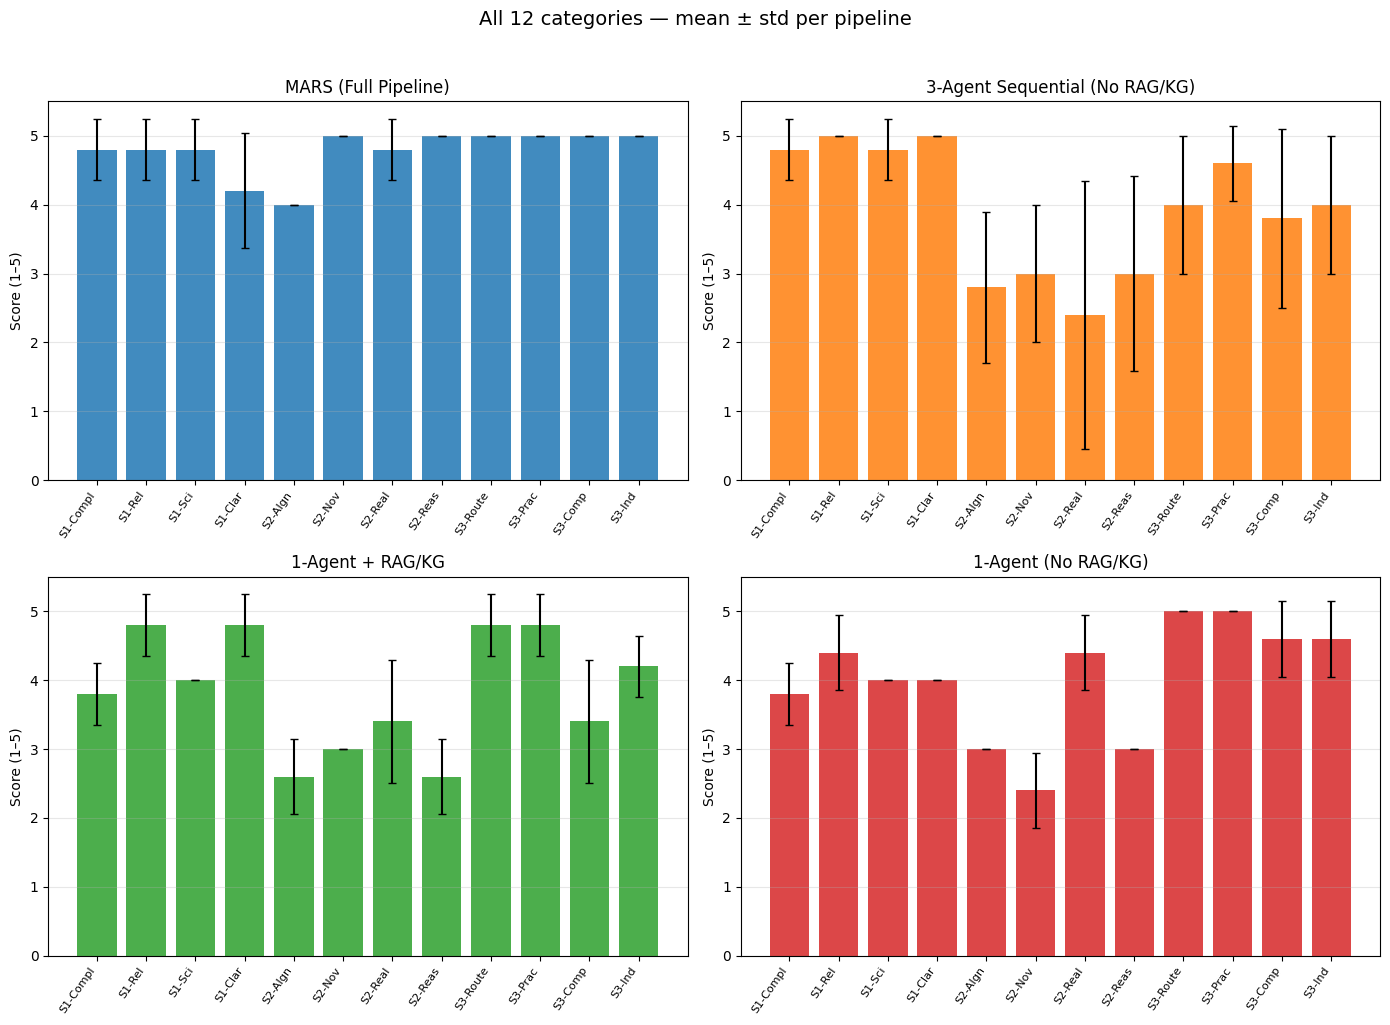

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, ck in enumerate(present_keys):
    ax = axes[idx]
    means = []
    stds = []
    for dk in ALL_DIM_KEYS:
        block = (conditions.get(ck) or {}).get(dk)
        if isinstance(block, dict):
            means.append(float(block["mean"]))
            stds.append(float(block["std"]))
        else:
            means.append(np.nan)
            stds.append(0.0)
    x = np.arange(len(ALL_DIM_KEYS))
    ax.bar(
        x,
        means,
        yerr=stds,
        capsize=3,
        color=colors_ordered[idx],
        ecolor="black",
        alpha=0.85,
    )
    ax.set_xticks(x)
    ax.set_xticklabels([short_label(k) for k in ALL_DIM_KEYS], rotation=55, ha="right", fontsize=8)
    ax.set_ylabel("Score (1–5)")
    ax.set_ylim(0, 5.5)
    ax.set_title(condition_label(ck))
    ax.grid(axis="y", alpha=0.3)

for j in range(len(present_keys), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("All 12 categories — mean ± std per pipeline", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Heatmap & ranks (optional overview)

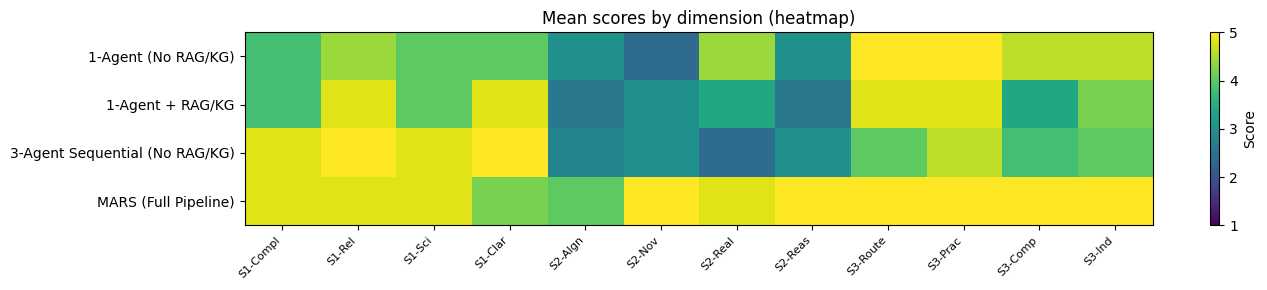

In [20]:
dim_rows = []
for ck in present_keys:
    block = conditions.get(ck) or {}
    label = block.get("label", ck)
    for k, v in block.items():
        if k in ("label", "weighted_avg"):
            continue
        if isinstance(v, dict) and "mean" in v:
            dim_rows.append(
                {"label": label, "dimension": k, "mean": v["mean"], "std": v["std"]}
            )

df_dims = pd.DataFrame(dim_rows)
if df_dims.empty:
    print("No per-dimension stats in summary.")
else:
    pivot = df_dims.pivot(index="label", columns="dimension", values="mean")
    pivot = pivot.reindex(columns=ALL_DIM_KEYS, fill_value=np.nan)
    fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 0.45)))
    im = ax.imshow(pivot.to_numpy(), aspect="auto", vmin=1, vmax=5, cmap="viridis")
    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels([short_label(c) for c in pivot.columns], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Mean scores by dimension (heatmap)")
    plt.colorbar(im, ax=ax, label="Score")
    plt.tight_layout()
    plt.show()

In [21]:
ranks = summary.get("avg_ranks") or {}
rank_rows = []
for ck in present_keys:
    stats = ranks.get(ck)
    if not isinstance(stats, dict):
        continue
    lbl = condition_label(ck)
    rank_rows.append(
        {"label": lbl, "mean_rank": stats["mean"], "std_rank": stats["std"]}
    )
df_ranks = pd.DataFrame(rank_rows).sort_values("mean_rank")
df_ranks

,label,mean_rank,std_rank
0,MARS (Full Pipeline),1.2,0.447214
2,1-Agent + RAG/KG,2.8,0.836660
1,3-Agent Sequential (No RAG/KG),3.0,1.414214
3,1-Agent (No RAG/KG),3.0,0.707107


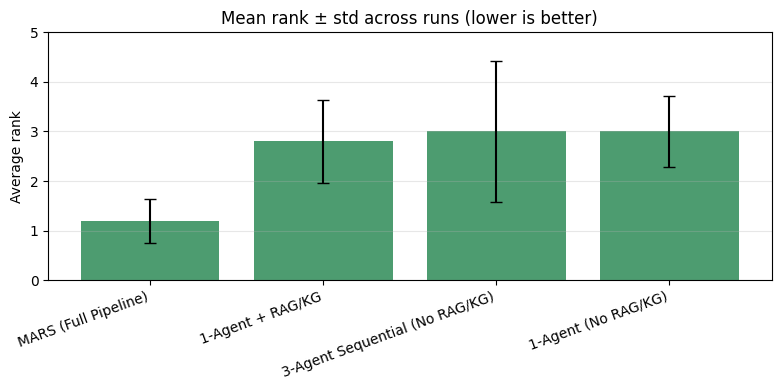

In [22]:
if not df_ranks.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(df_ranks))
    ax.bar(
        x,
        df_ranks["mean_rank"],
        yerr=df_ranks["std_rank"],
        capsize=4,
        color="seagreen",
        ecolor="black",
        alpha=0.85,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(df_ranks["label"], rotation=20, ha="right")
    ax.set_ylabel("Average rank")
    ax.set_title("Mean rank ± std across runs (lower is better)")
    ax.set_ylim(0, 5)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()